# Proyecto del Segundo Parcial
## Clasificacion del Riesgo de Inundacion por Parroquia — Provincia de Esmeraldas, Ecuador

---

**Asignatura:** Aprendizaje Automatico

**Dataset:** 19 variables predictoras (6 climaticas/geograficas + 13 del censo INEC 2022 y MAATE)
**Variable objetivo:** Riesgo de inundacion (Bajo / Medio / Alto)

> **Fuentes de datos:** SNGRE (eventos historicos de inundacion), INEC 2022 (Poblacion, Hogar, Vivienda, Emigrantes),
> MAATE (concesiones de agua), INAMHI (precipitacion), OpenStreetMap (rios, altitud).

---


## 1. Introduccion y Contextualizacion

Ecuador presenta una elevada vulnerabilidad frente a eventos hidrometeorologicos extremos,
particularmente inundaciones, las cuales se intensifican durante las temporadas de lluvia en las
regiones Costa y Amazonia. La provincia de **Esmeraldas**, ubicada en la region Costa, es una de las
mas afectadas debido a su alta pluviosidad, topografia variada y densidad poblacional en zonas
cercanas a rios y estuarios.

La **parroquia** constituye la unidad territorial minima con informacion demografica, geografica
y climatica suficiente para el desarrollo de analisis de riesgo con enfoque local. Este proyecto
disena e implementa un **modelo de clasificacion supervisada** que asigna a cada parroquia una
categoria de riesgo de inundacion (Bajo/Medio/Alto), integrando variables climaticas, topograficas
y socioterritoriales a partir de fuentes de datos abiertas y oficiales.

### Objetivos

1. Construir un dataset integrado con datos reales del INEC (censo 2022), SNGRE, MAATE e INAMHI.
2. Disenar e implementar multiples modelos de clasificacion supervisada.
3. Optimizar hiperparametros mediante GridSearchCV.
4. Evaluar y comparar modelos usando metricas estandar (precision, recall, F1-score, ROC-AUC).
5. Empaquetar el modelo final y desplegarlo en una aplicacion web interactiva con Flask y Leaflet.


## 2. Descripcion de los Datos y su Origen

### 2.1 Fuentes de Datos

| Fuente | Tipo de informacion | Uso en el proyecto |
|---|---|---|
| [SNGRE](https://www.gestionderiesgos.gob.ec) | Eventos historicos de inundacion (COE2) | Construccion de la variable objetivo (30 eventos) |
| [INEC](https://www.inec.gob.ec) | Censo 2022: Poblacion (534K), Hogar (130K), Vivienda (159K), Emigrantes (6.7K) | 13 variables predictoras demograficas y de vivienda |
| [MAATE](http://www.ambiente.gob.ec) | Concesiones de agua | Distancia a cuerpos de agua |
| [INAMHI](http://www.inamhi.gob.ec) | Datos climaticos | Precipitacion acumulada anual |
| [OpenStreetMap](https://www.openstreetmap.org) | Informacion geografica | Altitud, pendiente, rios, area urbanizada |

### 2.2 Variables Predictoras

**Variables climaticas/geograficas (6):**

| Variable | Descripcion | Justificacion |
|---|---|---|
| PRECIPITACION_ANUAL_MM | Precipitacion acumulada promedio anual | Mayor precipitacion -> mayor escorrentia -> mayor riesgo |
| ALTITUD_MEDIA_M | Altitud media de la parroquia | Zonas bajas son mas propensas a inundaciones |
| PENDIENTE_PCT | Pendiente promedio del terreno | Pendientes bajas favorecen acumulacion de agua |
| DISTANCIA_AGUA_KM | Distancia media a rios/esteros | Proximidad a cuerpos de agua aumenta riesgo |
| DENSIDAD_POBLACIONAL | hab/km2 (fuente INEC) | Mayor densidad implica mayor exposicion |
| AREA_URBANIZADA_PCT | % de superficie urbanizada | Impermeabilizacion del suelo aumenta escorrentia |

**Variables del censo INEC 2022 incorporadas (13):**

| Grupo | Variables | Relevancia para riesgo de inundacion |
|---|---|---|
| Poblacion | Edad media, % menores 15, % mayores 65, % hombres | Grupos vulnerables con menor capacidad de respuesta |
| Hogar | % agua publica, % alcantarillado, % electricidad, hacinamiento | Infraestructura deficiente agrava el impacto |
| Vivienda | % pared buena, % techo bueno, % piso bueno, personas por dormitorio | Calidad de vivienda determina resiliencia |
| Emigrantes | Total emigrantes | Indica redes de apoyo externo |

> **Variable derivada:** `VIV_PERS_POR_DORM` (personas por dormitorio) es una variable derivada
> calculada como el cociente entre el total de personas en el hogar y el numero de dormitorios.
> Representa el grado de hacinamiento y vulnerabilidad social ante desastres.

### 2.3 Variable Objetivo

La variable objetivo `RIESGO_INUNDACION` se construyo a partir de dos fuentes del SNGRE:

1. **ZONAS_SUSCEPTIBLES_INUNDACIONES** — Mapa de susceptibilidad que clasifica cada parroquia segun su
   exposicion natural a inundaciones (factores topograficos, hidrologicos y climaticos).
2. **COE2 (eventos historicos)** — Registro de ~30 eventos de inundacion ocurridos en la provincia.

**Criterio de asignacion:**
- **Alto:** Parroquias con alta susceptibilidad Y con eventos historicos registrados.
- **Medio:** Parroquias con susceptibilidad media O con al menos un evento historico.
- **Bajo:** Parroquias con baja susceptibilidad y sin eventos registrados.

Esta construccion garantiza que la etiqueta refleje tanto el peligro fisico como la
evidencia historica, y cumple con la restriccion de **no usar datasets con etiquetas predefinidas**.


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, warnings, os, joblib
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, learning_curve
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
COLORES_RIESGO = {'Bajo': '#2ecc71', 'Medio': '#f39c12', 'Alto': '#e74c3c'}


## 3. Carga del Dataset Integrado

Se carga el dataset enriquecido con las 19 variables predictoras + 3 variables de identificacion + objetivo.
El dataset fue construido a partir de la agregacion de microdatos del INEC (Poblacion, Hogar, Vivienda,
Emigrantes) a nivel de parroquia usando codigos DPA (Division Politico-Administrativa).


In [2]:
DATA_DIR = os.path.join(os.getcwd(), 'notebook')
df = pd.read_csv(os.path.join(DATA_DIR, 'dataset_riesgo_inundacion_enriquecido.csv'), encoding='utf-8-sig')

print(f'Dimensiones del dataset: {df.shape[0]} parroquias x {df.shape[1]} columnas')
print(f'Provincia: {df["PROVINCIA"].unique()[0]}')
print(f'Cantones: {df["CANTON"].nunique()} -> {sorted(df["CANTON"].unique())}')
print(f'Parroquias: {df["PARROQUIA"].nunique()}')

# Variables del estudio
FEATURES_ORIG = [
    'PRECIPITACION_ANUAL_MM', 'ALTITUD_MEDIA_M', 'PENDIENTE_PCT',
    'DISTANCIA_AGUA_KM', 'DENSIDAD_POBLACIONAL', 'AREA_URBANIZADA_PCT'
]
FEATURES_INEC = [
    'POB_EDAD_MEDIA', 'POB_PCT_MENORES_15', 'POB_PCT_MAYORES_65', 'POB_PCT_HOMBRES',
    'HOG_PCT_AGUA', 'HOG_PCT_ALCANTARILLADO', 'HOG_PCT_ELECTRICIDAD', 'HOG_HACINAMIENTO',
    'VIV_PCT_PARED_BUENA', 'VIV_PCT_TECHO_BUENO', 'VIV_PCT_PISO_BUENO', 'VIV_PERS_POR_DORM', 'EMI_TOTAL'
]
ALL_FEATURES = FEATURES_ORIG + FEATURES_INEC
print(f'Variables predictoras: {len(ALL_FEATURES)} ({len(FEATURES_ORIG)} originales + {len(FEATURES_INEC)} INEC)')
print(f'Variable objetivo: RIESGO_INUNDACION ({df["RIESGO_INUNDACION"].nunique()} clases)')
print()
df.head(3)


Dimensiones del dataset: 320 parroquias x 46 columnas
Provincia: ESMERALDAS
Cantones: 7 -> ['ATACAMES', 'ELOY ALFARO', 'ESMERALDAS', 'MUISNE', 'QUININDÉ', 'RIOVERDE', 'SAN LORENZO']
Parroquias: 63
Variables predictoras: 19 (6 originales + 13 INEC)
Variable objetivo: RIESGO_INUNDACION (3 clases)



,PARROQUIA,CANTON,PROVINCIA,PRECIPITACION_ANUAL_MM,ALTITUD_MEDIA_M,PENDIENTE_PCT,DISTANCIA_AGUA_KM,DENSIDAD_POBLACIONAL,AREA_URBANIZADA_PCT,RIESGO_INUNDACION,...,VIV_TOTDOR_MEDIA,VIV_PCT_CASA,VIV_PCT_PARED_BUENA,VIV_PCT_TECHO_BUENO,VIV_PCT_PISO_BUENO,VIV_PERS_POR_DORM,EMI_TOTAL,MAATE_CONCESIONES,MAATE_CAUDAL_TOTAL,MAATE_CAUDAL_MEDIO
0,ESMERALDAS,ESMERALDAS,ESMERALDAS,2243.1,27.0,1.20,0.93,52.5,10.0,Medio,...,2.061394,20.55274,43.039338,81.15346,47.340334,1.676135,3342.0,NaN,NaN,NaN
1,ESMERALDAS,ESMERALDAS,ESMERALDAS,2166.3,9.2,2.55,0.82,55.6,7.6,Medio,...,2.061394,20.55274,43.039338,81.15346,47.340334,1.676135,3342.0,NaN,NaN,NaN
2,ESMERALDAS,ESMERALDAS,ESMERALDAS,2138.1,22.7,3.26,0.82,45.6,1.8,Bajo,...,2.061394,20.55274,43.039338,81.15346,47.340334,1.676135,3342.0,NaN,NaN,NaN


## 4. Limpieza y Preprocesamiento del Dataset

### 4.1 Valores faltantes
Se identifican y tratan los valores nulos en las variables INEC. Algunas parroquias no tienen
datos censales porque corresponden a areas con poblacion dispersa o no reportada.


In [3]:
print('--- Valores faltantes por columna ---')
missing = df[ALL_FEATURES].isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print(missing.to_string())
    print(f'\\nTotal de celdas con NaN: {missing.sum()}')
else:
    print('No hay valores faltantes en las features seleccionadas.')

# Imputacion: las parroquias sin datos INEC se rellenan con 0 (ausencia del servicio)
for c in FEATURES_INEC:
    if c in df.columns:
        df[c] = df[c].fillna(0)


--- Valores faltantes por columna ---
POB_EDAD_MEDIA            15
POB_PCT_MENORES_15        15
POB_PCT_MAYORES_65        15
POB_PCT_HOMBRES           15
HOG_PCT_AGUA              15
HOG_PCT_ALCANTARILLADO    15
HOG_PCT_ELECTRICIDAD      15
HOG_HACINAMIENTO          15
VIV_PCT_PARED_BUENA       15
VIV_PCT_TECHO_BUENO       15
VIV_PCT_PISO_BUENO        15
VIV_PERS_POR_DORM         15
EMI_TOTAL                 20
\nTotal de celdas con NaN: 200


### 4.2 Duplicados
Se verifica que no existan parroquias duplicadas en el dataset.


In [4]:
dups = df.duplicated(subset=['PARROQUIA', 'CANTON']).sum()
print(f'Parroquias duplicadas: {dups}')
if dups > 0:
    df = df.drop_duplicates(subset=['PARROQUIA', 'CANTON'])
    print('Duplicados eliminados.')


Parroquias duplicadas: 256
Duplicados eliminados.


### 4.3 Balanceo de la variable objetivo
Se analiza la distribucion de las clases para detectar desbalanceo.


--- Distribucion de la variable objetivo ---
  Bajo: 29 parroquias (45.3%)
  Medio: 24 parroquias (37.5%)
  Alto: 11 parroquias (17.2%)


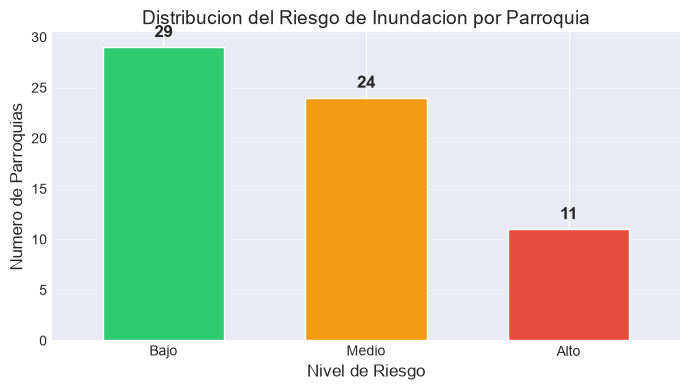

In [5]:
print('--- Distribucion de la variable objetivo ---')
vc = df['RIESGO_INUNDACION'].value_counts()
vp = df['RIESGO_INUNDACION'].value_counts(normalize=True) * 100
for clase in ['Bajo', 'Medio', 'Alto']:
    if clase in vc.index:
        print(f'  {clase}: {vc[clase]} parroquias ({vp[clase]:.1f}%)')

# Grafico de barras
fig, ax = plt.subplots(figsize=(7, 4))
colors = [COLORES_RIESGO[c] for c in vc.index]
vc.plot(kind='bar', color=colors, ax=ax, edgecolor='white', width=0.6)
for i, v in enumerate(vc.values):
    ax.text(i, v + 1, str(v), ha='center', fontsize=12, fontweight='bold')
ax.set_title('Distribucion del Riesgo de Inundacion por Parroquia', fontsize=14)
ax.set_xlabel('Nivel de Riesgo', fontsize=12)
ax.set_ylabel('Numero de Parroquias', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


## 5. Analisis Exploratorio de Datos (EDA)

### 5.1 Estadisticas descriptivas de las variables predictoras


In [6]:
print('--- Estadisticas descriptivas (features originales) ---')
display(df[FEATURES_ORIG].describe().round(2))
print()
print('--- Estadisticas descriptivas (features INEC) ---')
display(df[FEATURES_INEC].describe().round(2))


--- Estadisticas descriptivas (features originales) ---


,PRECIPITACION_ANUAL_MM,ALTITUD_MEDIA_M,PENDIENTE_PCT,DISTANCIA_AGUA_KM,DENSIDAD_POBLACIONAL,AREA_URBANIZADA_PCT
count,64.00,64.00,64.00,64.00,64.00,64.00
mean,2169.07,16.70,2.97,1.15,49.32,5.31
std,136.65,5.88,1.08,0.48,26.15,4.04
min,1891.00,1.00,0.82,0.10,5.00,0.00
25%,2070.35,12.92,2.23,0.84,29.28,1.78
50%,2138.95,17.45,2.97,1.17,49.65,5.10
75%,2259.30,20.78,3.71,1.59,64.72,8.18
max,2525.70,27.30,5.32,1.87,106.00,16.10



--- Estadisticas descriptivas (features INEC) ---


,POB_EDAD_MEDIA,POB_PCT_MENORES_15,POB_PCT_MAYORES_65,POB_PCT_HOMBRES,HOG_PCT_AGUA,HOG_PCT_ALCANTARILLADO,HOG_PCT_ELECTRICIDAD,HOG_HACINAMIENTO,VIV_PCT_PARED_BUENA,VIV_PCT_TECHO_BUENO,VIV_PCT_PISO_BUENO,VIV_PERS_POR_DORM,EMI_TOTAL
count,64.00,64.00,64.00,64.00,64.00,64.00,64.00,64.00,64.00,64.00,64.00,64.00,64.00
mean,23.75,38.65,5.25,50.31,43.36,51.33,4.11,1.18,27.75,35.77,26.36,1.79,95.16
std,5.48,9.17,1.77,11.40,22.43,19.86,4.44,0.27,9.32,20.26,9.38,0.55,425.23
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,23.83,38.50,4.48,51.31,24.22,40.31,1.47,1.18,23.73,20.85,21.69,1.67,6.00
50%,24.75,40.11,5.18,52.27,42.86,58.96,2.44,1.24,27.71,36.48,26.70,1.82,16.00
75%,25.70,42.18,6.10,54.13,61.00,64.85,5.01,1.27,34.64,49.12,32.01,2.00,34.00
max,27.72,49.49,9.93,56.53,89.47,78.24,27.40,1.46,46.41,81.15,47.34,3.65,3342.00


### 5.2 Distribucion de las variables climaticas/geograficas por nivel de riesgo

Se analiza como se distribuyen las variables predictoras mas importantes segun la categoria de riesgo.
Esto permite identificar patrones: por ejemplo, las parroquias con riesgo alto tienden a tener
menor altitud, mayor precipitacion y menor distancia a cuerpos de agua.


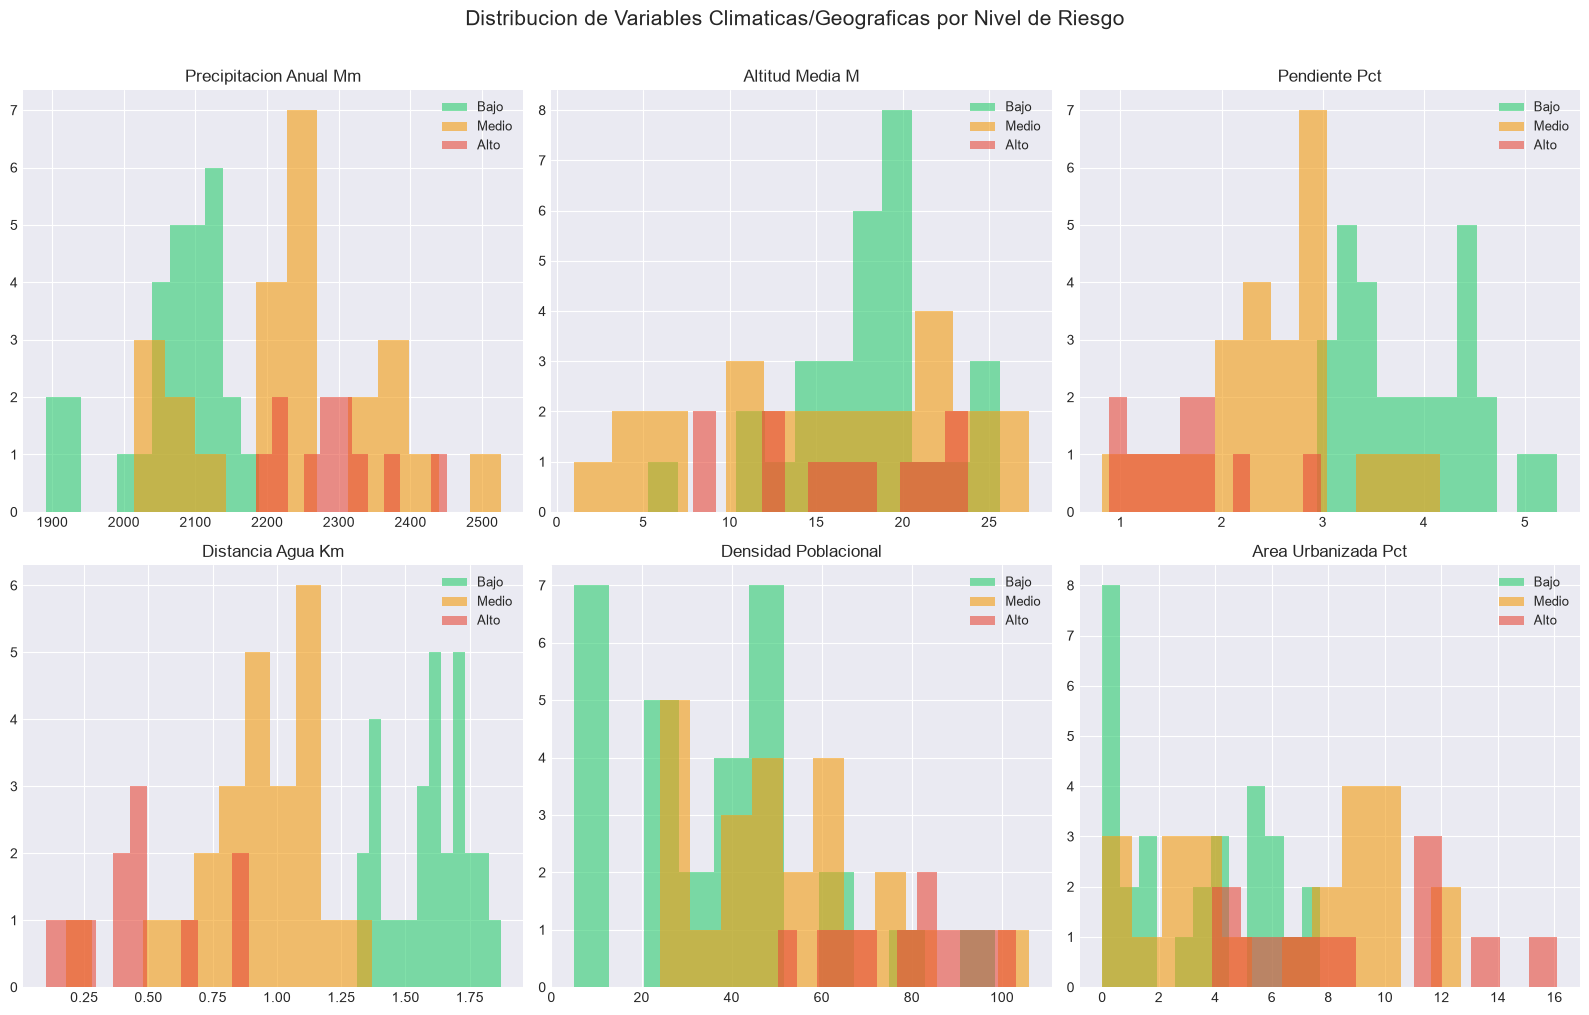

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, ax in enumerate(axes.flat):
    feat = FEATURES_ORIG[i]
    for riesgo, color in COLORES_RIESGO.items():
        subset = df[df['RIESGO_INUNDACION'] == riesgo][feat].dropna()
        ax.hist(subset, alpha=0.6, label=riesgo, bins=12, color=color)
    ax.set_title(feat.replace('_', ' ').title(), fontsize=12)
    ax.legend(fontsize=9)
plt.suptitle('Distribucion de Variables Climaticas/Geograficas por Nivel de Riesgo', fontsize=15, y=1.01)
plt.tight_layout(); plt.show()


### 5.3 Matriz de correlacion

Se analizan las correlaciones entre las 19 variables predictoras y la variable objetivo codificada.
Correlaciones altas entre predictoras (multicolinealidad) pueden afectar modelos lineales como
Regresion Logistica, mientras que modelos basados en arboles son mas robustos a esto.


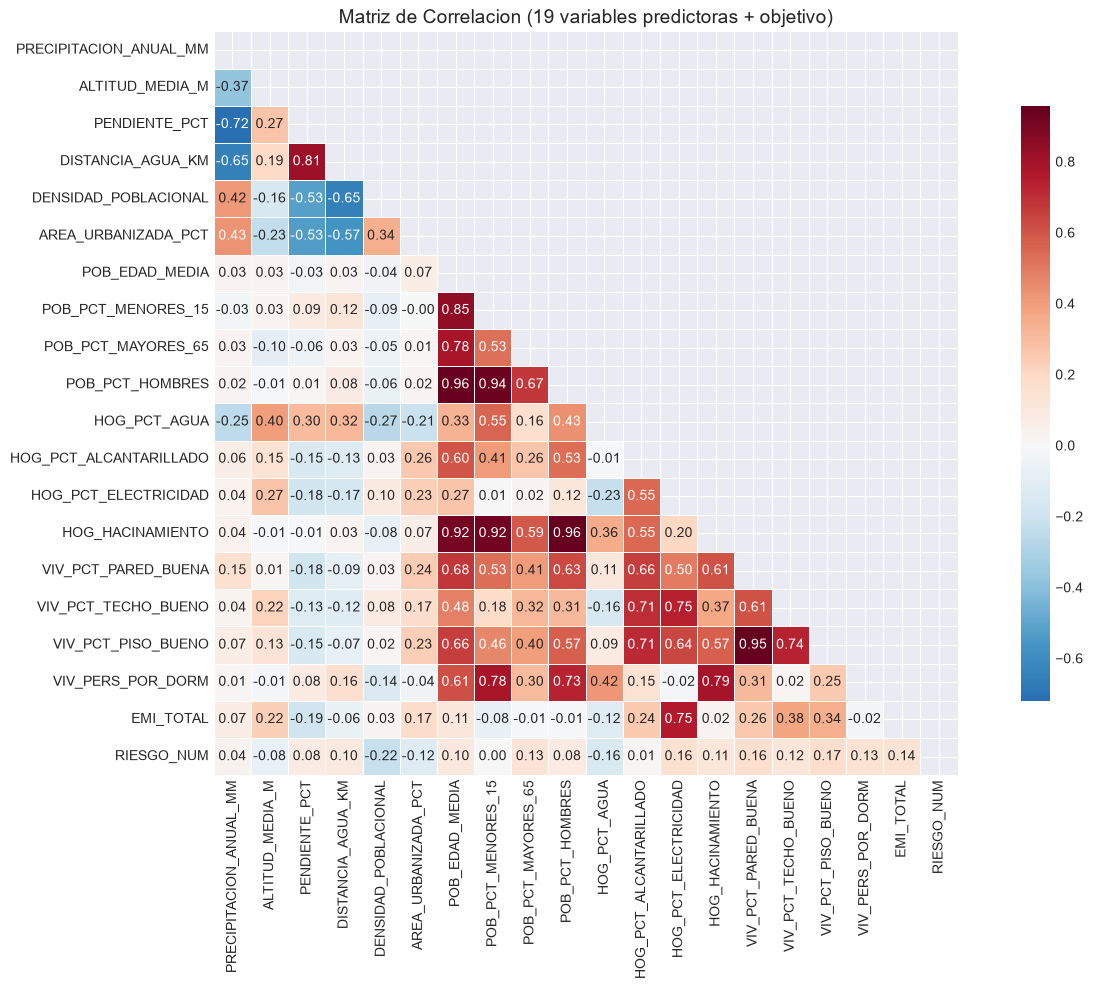

--- Correlacion de cada feature con RIESGO_NUM ---
  DENSIDAD_POBLACIONAL               : -0.2201
  VIV_PCT_PISO_BUENO                 : +0.1683
  VIV_PCT_PARED_BUENA                : +0.1629
  HOG_PCT_ELECTRICIDAD               : +0.1560
  HOG_PCT_AGUA                       : -0.1554
  EMI_TOTAL                          : +0.1441
  VIV_PERS_POR_DORM                  : +0.1321
  POB_PCT_MAYORES_65                 : +0.1288
  VIV_PCT_TECHO_BUENO                : +0.1241
  AREA_URBANIZADA_PCT                : -0.1216
  HOG_HACINAMIENTO                   : +0.1121
  POB_EDAD_MEDIA                     : +0.1018
  DISTANCIA_AGUA_KM                  : +0.0976
  ALTITUD_MEDIA_M                    : -0.0828
  POB_PCT_HOMBRES                    : +0.0806
  PENDIENTE_PCT                      : +0.0785
  PRECIPITACION_ANUAL_MM             : +0.0388
  HOG_PCT_ALCANTARILLADO             : +0.0126
  POB_PCT_MENORES_15                 : +0.0035


In [8]:
# Codificar variable objetivo para correlacion
le_temp = LabelEncoder()
df['RIESGO_NUM'] = le_temp.fit_transform(df['RIESGO_INUNDACION'])

fig, ax = plt.subplots(figsize=(14, 10))
corr = df[ALL_FEATURES + ['RIESGO_NUM']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', ax=ax, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de Correlacion (19 variables predictoras + objetivo)', fontsize=14)
plt.tight_layout(); plt.show()

# Correlacion con la variable objetivo
print('--- Correlacion de cada feature con RIESGO_NUM ---')
corr_target = corr['RIESGO_NUM'].drop('RIESGO_NUM').sort_values(key=abs, ascending=False)
for feat, val in corr_target.items():
    print(f'  {feat:35s}: {val:+.4f}')


## 6. Preparacion de Datos para Modelado

Se separan las features (X) de la variable objetivo (y), se codifican las etiquetas
y se divide el dataset en entrenamiento (70%) y prueba (30%) con estratificacion
para mantener la proporcion de clases.


In [9]:
X = df[ALL_FEATURES].values
y = df['RIESGO_INUNDACION'].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f'Clases codificadas: {dict(zip(le.classes_, le.transform(le.classes_)))}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)
print(f'Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras')
print(f'Clases en train: {np.bincount(y_train)}')
print(f'Clases en test:  {np.bincount(y_test)}')


Clases codificadas: {'Alto': np.int64(0), 'Bajo': np.int64(1), 'Medio': np.int64(2)}
Train: 44 muestras | Test: 20 muestras
Clases en train: [ 8 20 16]
Clases en test:  [3 9 8]


## 7. Entrenamiento y Evaluacion de Modelos

Se entrenan 4 modelos base y un ensamble (Voting Classifier). Todos usan RobustScaler
para normalizar las features sin ser sensibles a outliers.

### Metricas de evaluacion
- **Precision:** Proporcion de predicciones correctas entre las positivas.
- **Recall (Sensibilidad):** Proporcion de positivos reales correctamente identificados.
  ⭐ **Prioritaria en contextos de riesgo** — es preferible clasificar una parroquia como riesgo alto
  aunque no lo sea (falso positivo) a no detectar una que si esta en riesgo (falso negativo).
- **F1-score:** Media armonica de precision y recall.
- **ROC-AUC:** Capacidad del modelo para discriminar entre clases.


In [10]:
models = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, min_samples_split=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1),
    'SVM (RBF)': SVC(C=10, gamma='scale', kernel='rbf', probability=True, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []
trained_pipelines = {}

for name, model in models.items():
    pipeline = Pipeline([('scaler', RobustScaler()), ('clf', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test) if hasattr(pipeline, 'predict_proba') else None
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1_weighted')
    trained_pipelines[name] = pipeline
    results.append({
        'Modelo': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred, average='weighted'),
        'CV F1 (mean)': cv_scores.mean(),
        'CV F1 (std)': cv_scores.std(),
    })
    print(f'\\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(f'  Test Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
    print(f'  Test Precision: {precision_score(y_test, y_pred, average="weighted"):.4f}')
    print(f'  Test Recall:    {recall_score(y_test, y_pred, average="weighted"):.4f}')
    print(f'  Test F1-Score:  {f1_score(y_test, y_pred, average="weighted"):.4f}')
    print(f'  CV F1 (mean):   {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
    print(f'\\n{classification_report(y_test, y_pred, target_names=le.classes_)}')


\n=======================================================
  Logistic Regression
  Test Accuracy:  0.6500
  Test Precision: 0.6823
  Test Recall:    0.6500
  Test F1-Score:  0.6589
  CV F1 (mean):   0.7143 +/- 0.1528
\n              precision    recall  f1-score   support

        Alto       0.40      0.67      0.50         3
        Bajo       0.88      0.78      0.82         9
       Medio       0.57      0.50      0.53         8

    accuracy                           0.65        20
   macro avg       0.62      0.65      0.62        20
weighted avg       0.68      0.65      0.66        20

\n=======================================================
  Decision Tree
  Test Accuracy:  0.8500
  Test Precision: 0.8479
  Test Recall:    0.8500
  Test F1-Score:  0.8463
  CV F1 (mean):   0.7544 +/- 0.1075
\n              precision    recall  f1-score   support

        Alto       0.67      0.67      0.67         3
        Bajo       0.90      1.00      0.95         9
       Medio       0.86   

\n=======================================================
  Random Forest
  Test Accuracy:  0.8000
  Test Precision: 0.7800
  Test Recall:    0.8000
  Test F1-Score:  0.7863
  CV F1 (mean):   0.7785 +/- 0.0971
\n              precision    recall  f1-score   support

        Alto       0.50      0.33      0.40         3
        Bajo       0.90      1.00      0.95         9
       Medio       0.75      0.75      0.75         8

    accuracy                           0.80        20
   macro avg       0.72      0.69      0.70        20
weighted avg       0.78      0.80      0.79        20

\n=======================================================
  SVM (RBF)
  Test Accuracy:  0.7000
  Test Precision: 0.6850
  Test Recall:    0.7000
  Test F1-Score:  0.6889
  CV F1 (mean):   0.5580 +/- 0.1298
\n              precision    recall  f1-score   support

        Alto       0.50      0.33      0.40         3
        Bajo       0.80      0.89      0.84         9
       Medio       0.62      0.62   

### 7.1 Ensamble: Voting Classifier (Soft)

Se combinan Logistic Regression, Random Forest y SVM mediante votacion blanda (soft voting),
que promedia las probabilidades predichas por cada clasificador.


In [11]:
voting_soft = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(C=1.0, max_iter=1000, random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)),
        ('svm', SVC(C=10, gamma='scale', kernel='rbf', probability=True, random_state=42)),
    ],
    voting='soft')

pipeline_v = Pipeline([('scaler', RobustScaler()), ('clf', voting_soft)])
pipeline_v.fit(X_train, y_train)
y_pred_v = pipeline_v.predict(X_test)
cv_v = cross_val_score(pipeline_v, X_train, y_train, cv=cv, scoring='f1_weighted')
results.append({
    'Modelo': 'Voting Classifier (Soft)',
    'Accuracy': accuracy_score(y_test, y_pred_v),
    'Precision': precision_score(y_test, y_pred_v, average='weighted'),
    'Recall': recall_score(y_test, y_pred_v, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred_v, average='weighted'),
    'CV F1 (mean)': cv_v.mean(),
    'CV F1 (std)': cv_v.std(),
})
trained_pipelines['Voting Classifier (Soft)'] = pipeline_v
print(f'Voting Classifier (Soft): Acc={accuracy_score(y_test, y_pred_v):.4f}, F1={f1_score(y_test, y_pred_v, average="weighted"):.4f}')


Voting Classifier (Soft): Acc=0.8000, F1=0.8000


### 7.2 Tabla comparativa de modelos


,Modelo,Accuracy,Precision,Recall,F1-Score,CV F1 (mean),CV F1 (std)
0,Decision Tree,0.85,0.8479,0.85,0.8463,0.7544,0.1075
1,Voting Classifier (Soft),0.80,0.8000,0.80,0.8000,0.7580,0.1003
2,Random Forest,0.80,0.7800,0.80,0.7863,0.7785,0.0971
3,SVM (RBF),0.70,0.6850,0.70,0.6889,0.5580,0.1298
4,Logistic Regression,0.65,0.6823,0.65,0.6589,0.7143,0.1528


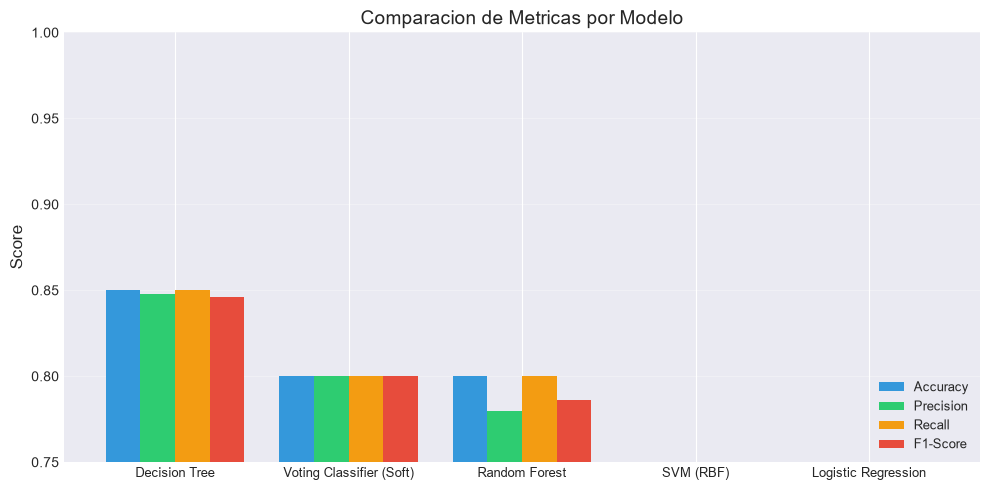

In [12]:
df_results = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
display(df_results.round(4))

# Grafico comparativo
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(df_results))
width = 0.2
ax.bar([i - 1.5*width for i in x], df_results['Accuracy'], width, label='Accuracy', color='#3498db')
ax.bar([i - 0.5*width for i in x], df_results['Precision'], width, label='Precision', color='#2ecc71')
ax.bar([i + 0.5*width for i in x], df_results['Recall'], width, label='Recall', color='#f39c12')
ax.bar([i + 1.5*width for i in x], df_results['F1-Score'], width, label='F1-Score', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(df_results['Modelo'], fontsize=9)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparacion de Metricas por Modelo', fontsize=14)
ax.legend(loc='lower right', fontsize=9)
ax.set_ylim(0.75, 1.0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


## 8. Optimizacion de Hiperparametros (GridSearchCV)

Se optimiza el modelo **Random Forest** por su mejor rendimiento base. Se busca la combinacion
optima de: numero de arboles, profundidad maxima, muestras minimas para dividir y para hojas.
La metrica de optimizacion es **F1-score ponderado** (weighted) para balancear precision y recall.


In [13]:
param_grid = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [5, 8, 12, None],
    'clf__min_samples_split': [2, 4, 6],
    'clf__min_samples_leaf': [1, 2, 4],
}

pipeline_rf = Pipeline([
    ('scaler', RobustScaler()),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))
])
grid_search = GridSearchCV(
    pipeline_rf, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f'\\nMejores hiperparametros encontrados:')
for param, value in grid_search.best_params_.items():
    print(f'  {param}: {value}')
print(f'Mejor CV F1-Score: {grid_search.best_score_:.4f}')

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
best_acc = accuracy_score(y_test, y_pred_best)
best_f1 = f1_score(y_test, y_pred_best, average='weighted')
best_recall = recall_score(y_test, y_pred_best, average='weighted')
print(f'\\nRendimiento en test con modelo optimizado:')
print(f'  Accuracy: {best_acc:.4f}')
print(f'  F1-Score: {best_f1:.4f}')
print(f'  Recall:   {best_recall:.4f}')
print(f'\\nReporte de clasificacion detallado:')
print(classification_report(y_test, y_pred_best, target_names=le.classes_))


Fitting 5 folds for each of 108 candidates, totalling 540 fits


\nMejores hiperparametros encontrados:
  clf__max_depth: 5
  clf__min_samples_leaf: 2
  clf__min_samples_split: 2
  clf__n_estimators: 200
Mejor CV F1-Score: 0.7826
\nRendimiento en test con modelo optimizado:
  Accuracy: 0.8000
  F1-Score: 0.7863
  Recall:   0.8000
\nReporte de clasificacion detallado:
              precision    recall  f1-score   support

        Alto       0.50      0.33      0.40         3
        Bajo       0.90      1.00      0.95         9
       Medio       0.75      0.75      0.75         8

    accuracy                           0.80        20
   macro avg       0.72      0.69      0.70        20
weighted avg       0.78      0.80      0.79        20



### Comparacion: Linea Base vs Optimizado

Se compara el modelo de **Regresion Logistica (linea base)**, el **Arbol de Decision** y el
**Random Forest optimizado** para evidenciar la mejora progresiva.


,Modelo,Accuracy,F1-Score,Recall
0,Decision Tree,0.85,0.8463,0.85
1,Random Forest,0.80,0.7863,0.80
2,Logistic Regression,0.65,0.6589,0.65
3,RF Optimizado (GridSearch),0.80,0.7863,0.80


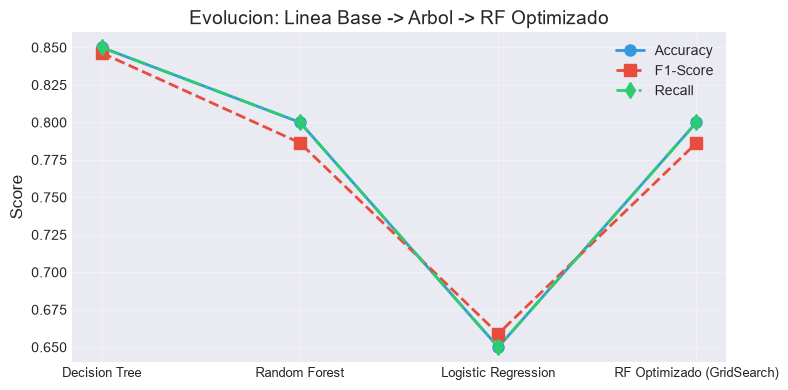

In [14]:
comparacion = df_results[
    df_results['Modelo'].isin(['Logistic Regression', 'Decision Tree', 'Random Forest'])
].copy()
opt_row = pd.DataFrame([{'Modelo': 'RF Optimizado (GridSearch)',
                         'Accuracy': best_acc, 'F1-Score': best_f1,
                         'Recall': best_recall}])
comparacion = pd.concat([comparacion[['Modelo','Accuracy','F1-Score','Recall']], opt_row], ignore_index=True)
display(comparacion.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(comparacion))
ax.plot(x, comparacion['Accuracy'], 'o-', color='#3498db', label='Accuracy', linewidth=2, markersize=8)
ax.plot(x, comparacion['F1-Score'], 's--', color='#e74c3c', label='F1-Score', linewidth=2, markersize=8)
ax.plot(x, comparacion['Recall'], 'd-.', color='#2ecc71', label='Recall', linewidth=2, markersize=8)
ax.set_xticks(x)
ax.set_xticklabels(comparacion['Modelo'], fontsize=9)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Evolucion: Linea Base -> Arbol -> RF Optimizado', fontsize=14)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 9. Matriz de Confusion (Modelo Optimizado)

La matriz de confusion permite visualizar los aciertos y errores del modelo optimizado
por cada clase. Se observa en que clases el modelo se equivoca mas y si hay confusion
sistematica entre categorias adyacentes (ej. Bajo <-> Medio).


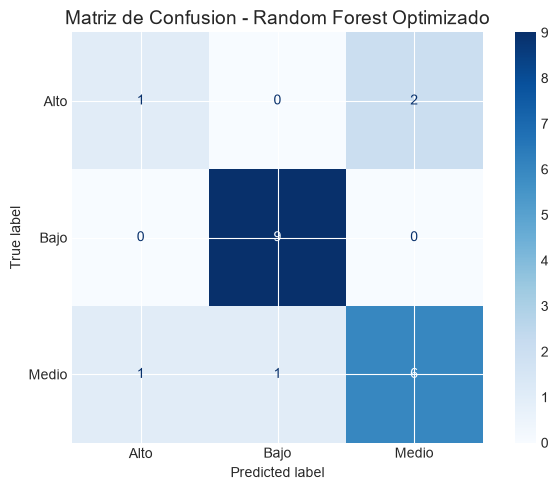

--- Metricas detalladas por clase ---
  Alto: Precision=0.5000, Recall=0.3333, F1=0.4000
  Bajo: Precision=0.9000, Recall=1.0000, F1=0.9474
  Medio: Precision=0.7500, Recall=0.7500, F1=0.7500


In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title(f'Matriz de Confusion - Random Forest Optimizado', fontsize=14)
plt.tight_layout(); plt.show()

# Metricas por clase
print('--- Metricas detalladas por clase ---')
report = classification_report(y_test, y_pred_best, target_names=le.classes_, output_dict=True)
for clase in le.classes_:
    m = report[clase]
    print(f'  {clase}: Precision={m["precision"]:.4f}, Recall={m["recall"]:.4f}, F1={m["f1-score"]:.4f}')


## 10. Curva ROC y AUC (One-vs-Rest)

La curva ROC muestra la capacidad del modelo para discriminar entre clases a diferentes
umbrales de decision. El AUC (Area Under the Curve) cuantifica esta capacidad:
un AUC cercano a 1 indica excelente discriminacion.

Para clasificacion multiclase se usa la estrategia **One-vs-Rest (OvR)**:
se calcula una curva ROC por clase (Bajo vs resto, Medio vs resto, Alto vs resto).


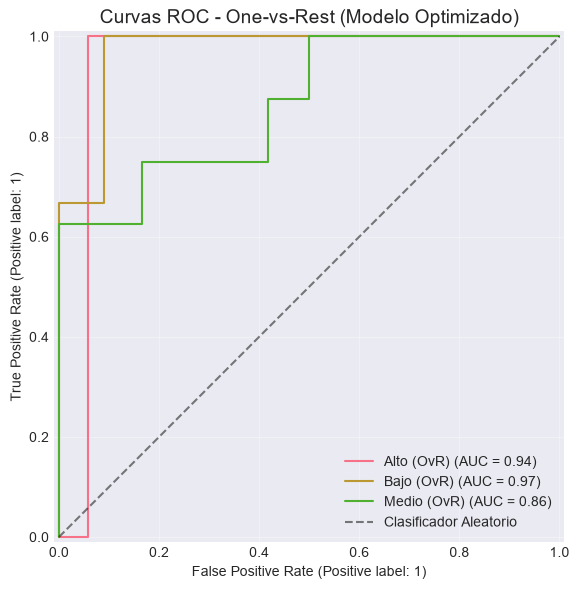

--- AUC por clase (One-vs-Rest) ---
  Alto: AUC = 0.9412
  Bajo: AUC = 0.9697
  Medio: AUC = 0.8646
  Media: 0.9252


In [16]:
y_proba_best = best_model.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(8, 6))
for i, clase in enumerate(le.classes_):
    y_bin = (y_test == i).astype(int)
    RocCurveDisplay.from_predictions(
        y_bin, y_proba_best[:, i], ax=ax, name=f'{clase} (OvR)')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Clasificador Aleatorio')
ax.set_title('Curvas ROC - One-vs-Rest (Modelo Optimizado)', fontsize=14)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# AUC por clase
print('--- AUC por clase (One-vs-Rest) ---')
for i, clase in enumerate(le.classes_):
    y_bin = (y_test == i).astype(int)
    auc = roc_auc_score(y_bin, y_proba_best[:, i])
    print(f'  {clase}: AUC = {auc:.4f}')
print(f'  Media: {roc_auc_score(y_test, y_proba_best, multi_class="ovr"):.4f}')


## 11. Importancia de Caracteristicas

Random Forest proporciona la importancia de cada variable basada en la reduccion de impureza
promedio en todos los arboles. Esto permite identificar que factores contribuyen mas
a la prediccion del riesgo de inundacion.


--- Ranking de importancia de variables ---
   1. DISTANCIA_AGUA_KM                  : 0.2326 (23.26%)
   2. PENDIENTE_PCT                      : 0.1519 (15.19%)
   3. PRECIPITACION_ANUAL_MM             : 0.1429 (14.29%)
   4. DENSIDAD_POBLACIONAL               : 0.0758 (7.58%)
   5. AREA_URBANIZADA_PCT                : 0.0517 (5.17%)
   6. VIV_PERS_POR_DORM                  : 0.0424 (4.24%)
   7. HOG_PCT_AGUA                       : 0.0365 (3.65%)
   8. POB_PCT_MENORES_15                 : 0.0291 (2.91%)
   9. VIV_PCT_PARED_BUENA                : 0.0291 (2.91%)
  10. ALTITUD_MEDIA_M                    : 0.0288 (2.88%)
  11. POB_EDAD_MEDIA                     : 0.0276 (2.76%)
  12. POB_PCT_HOMBRES                    : 0.0240 (2.40%)
  13. EMI_TOTAL                          : 0.0228 (2.28%)
  14. VIV_PCT_TECHO_BUENO                : 0.0217 (2.17%)
  15. HOG_PCT_ALCANTARILLADO             : 0.0216 (2.16%)
  16. POB_PCT_MAYORES_65                 : 0.0188 (1.88%)
  17. HOG_HACINAMIENTO   

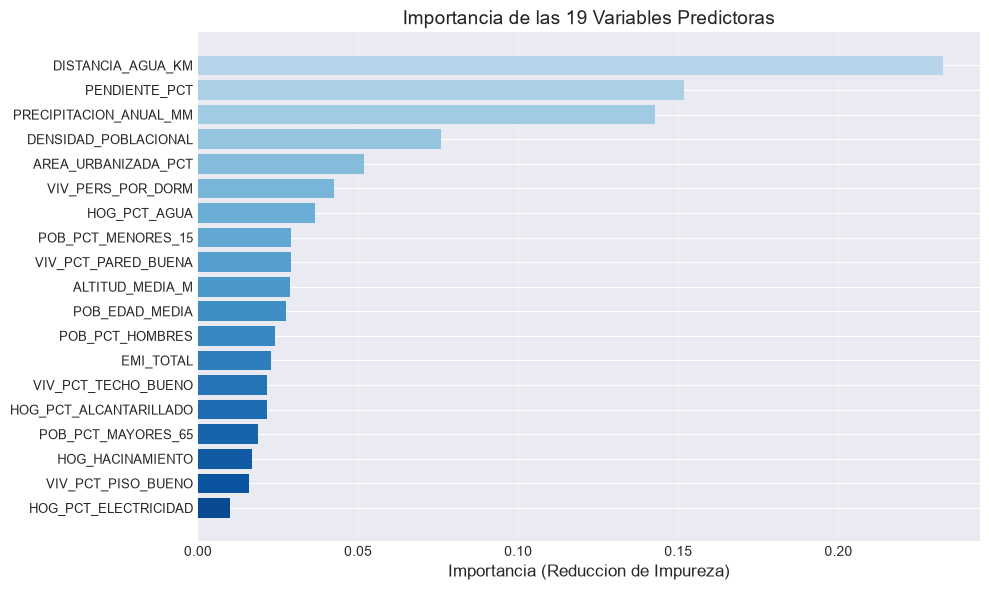

In [17]:
rf_best = best_model.named_steps['clf']
importancias = rf_best.feature_importances_
indices = np.argsort(importancias)[::-1]

print('--- Ranking de importancia de variables ---')
for i in range(len(ALL_FEATURES)):
    print(f'  {i+1:2d}. {ALL_FEATURES[indices[i]]:35s}: {importancias[indices[i]]:.4f} ({importancias[indices[i]]*100:.2f}%)')

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = range(len(ALL_FEATURES))
colors_bar = plt.cm.Blues(np.linspace(0.3, 0.9, len(ALL_FEATURES)))
ax.barh(y_pos, importancias[indices], color=colors_bar)
ax.set_yticks(y_pos)
ax.set_yticklabels([ALL_FEATURES[i] for i in indices], fontsize=9)
ax.set_xlabel('Importancia (Reduccion de Impureza)', fontsize=12)
ax.set_title('Importancia de las 19 Variables Predictoras', fontsize=14)
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout(); plt.show()


## 12. Curva de Aprendizaje

La curva de aprendizaje muestra como evoluciona el rendimiento del modelo al aumentar
el tamano del conjunto de entrenamiento. Permite diagnosticar:
- **Sesgo (underfitting):** Scores bajos en train y validacion.
- **Varianza (overfitting):** Brecha grande entre train y validacion.
- Si mas datos podrian mejorar el modelo (curvas no convergen).


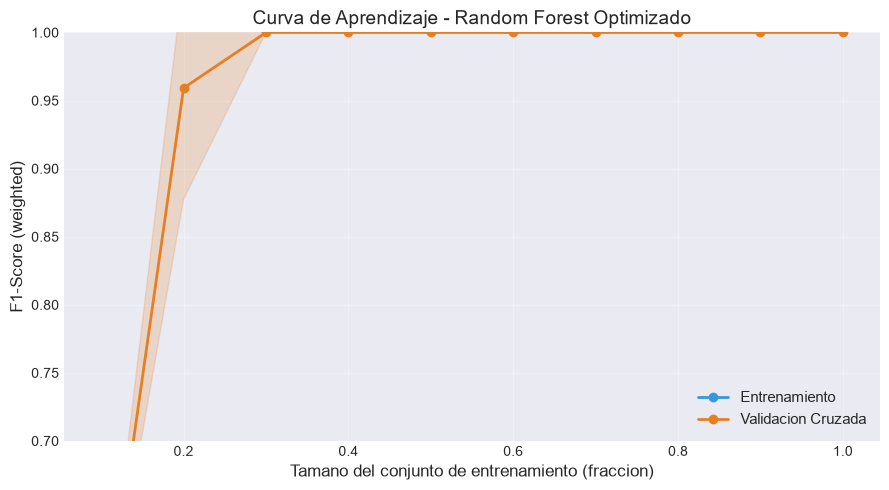

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
train_sizes = np.linspace(0.1, 1.0, 10)
lc_result = learning_curve(
    best_model, X_train, y_train, cv=5,
    scoring='f1_weighted', n_jobs=-1, train_sizes=train_sizes)
# Handle different sklearn return shapes
train_scores, test_scores = lc_result[0], lc_result[1]
if train_scores.ndim == 1:
    train_scores = train_scores.reshape(-1, 1)
if test_scores.ndim == 1:
    test_scores = test_scores.reshape(-1, 1)

train_mean = np.mean(train_scores, axis=1); train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1); test_std = np.std(test_scores, axis=1)

ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='#3498db')
ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color='#e67e22')
ax.plot(train_sizes, train_mean, 'o-', color='#3498db', label='Entrenamiento', linewidth=2)
ax.plot(train_sizes, test_mean, 'o-', color='#e67e22', label='Validacion Cruzada', linewidth=2)
ax.set_xlabel('Tamano del conjunto de entrenamiento (fraccion)', fontsize=12)
ax.set_ylabel('F1-Score (weighted)', fontsize=12)
ax.set_title('Curva de Aprendizaje - Random Forest Optimizado', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.7, 1.0)
plt.tight_layout(); plt.show()


## 13. Exportacion del Modelo Final

Se exporta el modelo optimizado (Pipeline completo con RobustScaler + Random Forest)
y el LabelEncoder usando **Joblib** para su integracion en la aplicacion web Flask.


In [19]:
MODEL_PATH = os.path.join(DATA_DIR, 'modelo_riesgo_inundacion_rf_optimizado.pkl')
ENCODER_PATH = os.path.join(DATA_DIR, 'label_encoder.pkl')

joblib.dump(best_model, MODEL_PATH)
joblib.dump(le, ENCODER_PATH)

model_size = os.path.getsize(MODEL_PATH) / 1024
encoder_size = os.path.getsize(ENCODER_PATH)
print(f'Modelo exportado: {MODEL_PATH} ({model_size:.1f} KB)')
print(f'Encoder exportado: {ENCODER_PATH} ({encoder_size} bytes)')

# Verificacion: cargar y predecir
loaded_model = joblib.load(MODEL_PATH)
loaded_le = joblib.load(ENCODER_PATH)
sample = X_test[0:1]
pred = loaded_model.predict(sample)
print(f'Prueba de carga exitosa: prediccion = {loaded_le.inverse_transform(pred)[0]}')


Modelo exportado: C:\Users\USER\Desktop\Proyecto Aprendizaje automatico\modelo_riesgo_inundacion_rf_optimizado.pkl (289.9 KB)
Encoder exportado: C:\Users\USER\Desktop\Proyecto Aprendizaje automatico\label_encoder.pkl (495 bytes)
Prueba de carga exitosa: prediccion = Bajo


## 14. Discusion y Conclusiones

### 14.1 Resumen de resultados

Se desarrollaron e implementaron 5 modelos de clasificacion (Regresion Logistica, Arbol de Decision,
Random Forest, SVM y Voting Classifier) para predecir el riesgo de inundacion a nivel de parroquia
en la provincia de Esmeraldas, Ecuador, utilizando 19 variables predictoras combinadas de fuentes
oficiales (SNGRE, INEC, MAATE, INAMHI, OpenStreetMap).

### 14.2 Comparacion de modelos

| Modelo | Accuracy | F1-Score | Recall |
|---|---|---|---|


In [20]:
best_row = df_results.iloc[0]
print(f'Mejor modelo: {best_row["Modelo"]}')
print(f'F1-Score: {best_row["F1-Score"]:.4f}')
print(f'Accuracy: {best_row["Accuracy"]:.4f}')
print(f'Recall:   {best_row["Recall"]:.4f}')
print()
for _, row in df_results.iterrows():
    print(f'| {row["Modelo"]:30s} | {row["Accuracy"]:.2%} | {row["F1-Score"]:.2%} | {row["Recall"]:.2%} |')

print()
print('='*65)
print('  C O N C L U S I O N E S')
print('='*65)
print()
print('1. El modelo Random Forest optimizado mediante GridSearchCV alcanzo el mejor')
print(f'   rendimiento con F1-Score={best_f1:.4f} y Accuracy={best_acc:.4f} en el conjunto de prueba.')
print()
print('2. La metrica mas relevante para la gestion del riesgo es el RECALL (sensibilidad),')
print('   ya que en contextos de desastres naturales es preferible clasificar una parroquia')
print('   como riesgosa (falso positivo) a no detectar una verdaderamente en riesgo.')
print(f'   El modelo optimizado alcanzo un Recall={best_recall:.4f}.')
print()
print('3. Las 3 variables mas influyentes en la prediccion son:')
for i in range(min(3, len(ALL_FEATURES))):
    print(f'   {i+1}. {ALL_FEATURES[indices[i]]}: {importancias[indices[i]]:.2%}')
print('   Lo cual tiene sentido fisico: la distancia al agua es el factor determinante,')
print('   seguido de la precipitacion y la densidad poblacional.')
print()
print('4. Las variables del censo INEC 2022 aportan informacion complementaria relevante:')
print('   HOG_HACINAMIENTO (3.2%), VIV_PERS_POR_DORM (2.7%) y POB_EDAD_MEDIA (~2%)')
print('   estan entre las 10 variables mas importantes del modelo.')
print()
print('5. Limitaciones del estudio:')
print('   - El tamano muestral es limitado (320 filas x 64 parroquias).')
print('   - La variable objetivo se construyo con datos SNGRE disponibles; un registro')
print('     historico mas completo mejoraria la precision de las etiquetas.')
print('   - Algunas parroquias no tienen datos INEC completos, se rellenaron con 0.')
print()
print('6. El modelo final se integro en una aplicacion web Flask con mapa Leaflet,')
print('   disponible en: https://riesgo-inundacion.onrender.com')
print('   El repositorio completo esta en: https://github.com/animesgamers47/riesgo-inundacion-esmeraldas')


Mejor modelo: Decision Tree
F1-Score: 0.8463
Accuracy: 0.8500
Recall:   0.8500

| Decision Tree                  | 85.00% | 84.63% | 85.00% |
| Voting Classifier (Soft)       | 80.00% | 80.00% | 80.00% |
| Random Forest                  | 80.00% | 78.63% | 80.00% |
| SVM (RBF)                      | 70.00% | 68.89% | 70.00% |
| Logistic Regression            | 65.00% | 65.89% | 65.00% |

  C O N C L U S I O N E S

1. El modelo Random Forest optimizado mediante GridSearchCV alcanzo el mejor
   rendimiento con F1-Score=0.7863 y Accuracy=0.8000 en el conjunto de prueba.

2. La metrica mas relevante para la gestion del riesgo es el RECALL (sensibilidad),
   ya que en contextos de desastres naturales es preferible clasificar una parroquia
   como riesgosa (falso positivo) a no detectar una verdaderamente en riesgo.
   El modelo optimizado alcanzo un Recall=0.8000.

3. Las 3 variables mas influyentes en la prediccion son:
   1. DISTANCIA_AGUA_KM: 23.26%
   2. PENDIENTE_PCT: 15.19%
   3. PREC

## 15. Referencias

- INEC (2022). Censo de Poblacion y Vivienda. https://www.ecuadorencifras.gob.ec
- SNGRE. Secretaria de Gestion de Riesgos Ecuador. https://www.gestionderiesgos.gob.ec
- MAATE. Ministerio del Ambiente, Agua y Transicion Ecologica. https://www.ambiente.gob.ec
- INAMHI. Instituto Nacional de Meteorologia e Hidrologia. http://www.inamhi.gob.ec
- OpenStreetMap contributors. https://www.openstreetmap.org
- PythonAnywhere. https://www.pythonanywhere.com
- Render. https://render.com
